<a href="https://colab.research.google.com/github/prashantbkoli/Machine-Learning/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First Five Records
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Intercept:
-37.02327770606409

Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Model Performance
MAE : 0.533
MSE : 0.556
RMSE: 0.746
R2 Score: 0.576

A

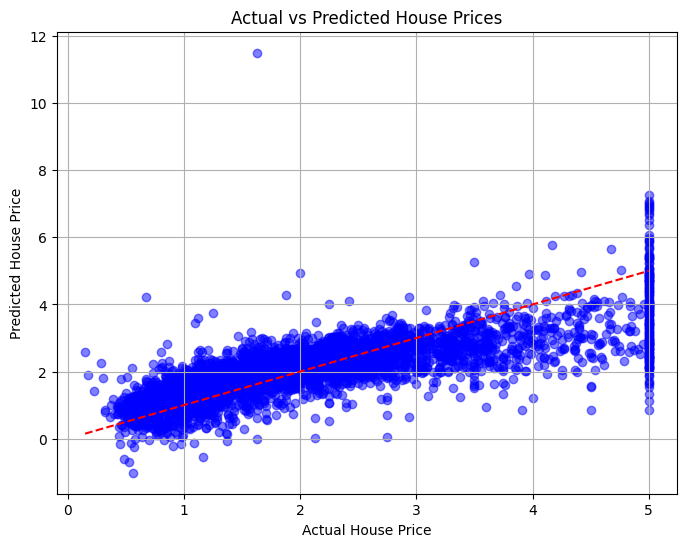

In [ ]:
# House Price Prediction using Linear Regression

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['HousePrice'] = housing.target

# Display first five rows
print("First Five Records")
print(df.head())

# Step 3: Define Features and Target
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

# Step 4: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Predict House Prices
y_pred = model.predict(X_test)

# Step 7: Model Parameters
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coef)

# Step 8: Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 3))

# Step 9: Actual vs Predicted Values
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nActual vs Predicted")
print(result.head(10))

# Step 10: Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()